In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn as skl
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

/home/pict/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [4]:
df=pd.read_csv("housing.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       501 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [5]:
df.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         5
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [6]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,501.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284341,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.705587,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.884000,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208000,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.625000,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [7]:
# Calculate the mean and fill the missing values, then overwrite the column
df["rm"] = df["rm"].fillna(df["rm"].mean())
# Check for missing values
df.isna().sum()

crim       0
zn         0
indus      0
chas       0
nox        0
rm         0
age        0
dis        0
rad        0
tax        0
ptratio    0
b          0
lstat      0
medv       0
dtype: int64

In [8]:
# convert all columns from 64 bit to 32 bit to save memory (float64 to float32 and int64 to int32)
for col in df.columns:
    if df[col].dtype == 'float64':
        df[col] = df[col].astype('float32')
    if df[col].dtype == 'int64':
        df[col] = df[col].astype('int32')

In [18]:
def handle_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[column] = np.where(df[column] < lower_bound, lower_bound, df[column])
    df[column] = np.where(df[column] > upper_bound, upper_bound, df[column])
    return df

numerical_cols = df.select_dtypes(include='number').columns
for col in numerical_cols:
    df = handle_outliers(df, col)

In [19]:
def train_test_split_scratch(X, y, test_size=0.2, random_state=None):
    if random_state is not None:
        np.random.seed(random_state)
    n_samples = X.shape[0]
    shuffled_indices = np.random.permutation(n_samples)
    split_index = int(n_samples * (1 - test_size))
    
    train_indices = shuffled_indices[:split_index]
    test_indices = shuffled_indices[split_index:]
    
    return X[train_indices], X[test_indices], y[train_indices], y[test_indices]


def mse_scratch(y_true, y_pred):
    """
    Calculates the Mean Squared Error.
    """
    # Calculate the squared differences, then find the mean
    return np.mean((y_true - y_pred) ** 2)

def r2_score_scratch(y_true, y_pred):
    """
    Calculates the R-squared (Coefficient of Determination) score.
    """
    # Sum of squared residuals (errors)
    ss_res = np.sum((y_true - y_pred) ** 2)
    
    # Total sum of squares (variance of the data)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    
    # R-squared formula
    # Handle the edge case where ss_tot is 0 (constant target)
    if ss_tot == 0:
        return 0.0
        
    return 1 - (ss_res / ss_tot)

In [20]:

class StandardScalerScratch:
    def __init__(self):
        self.mean = None
        self.std = None
        
    def fit_transform(self, X):
        # Calculate mean and standard deviation for each column
        self.mean = np.mean(X, axis=0)
        self.std = np.std(X, axis=0)
        # Avoid division by zero just in case a column is constant
        self.std[self.std == 0] = 1e-8 
        return (X - self.mean) / self.std
        
    def transform(self, X):
        return (X - self.mean) / self.std

class LinearRegressionGradientDescent:
    def __init__(self, learning_rate=0.01, epochs=1000):
        self.lr = learning_rate
        self.epochs = epochs
        self.weights = None
        self.bias = None
        
    def fit(self, X, y):
        n_samples, n_features = X.shape
        
        # 1. Initialize weights to zero and bias to 0
        self.weights = np.zeros(n_features)
        self.bias = 0
        
        # 2. Iteratively update weights
        for _ in range(self.epochs):
            # Calculate predictions (X dot weights + bias)
            # Shape: (m, n) dot (n,) -> outputs (m,)
            y_pred = np.dot(X, self.weights) + self.bias
            
            # Calculate the error
            error = y_pred - y
            
            # Calculate gradients WITHOUT transpose
            # np.dot(1D_array, 2D_array) automatically sums over the matching axes
            dw = np.dot(error, X) / n_samples
            db = np.mean(error)
            
            # Take a step to update parameters
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
    
            
    def predict(self, X):
        return np.dot(X, self.weights) + self.bias

# --- Applying it to your dataframe ---

# 1. Separate features and target
X = df.drop('medv', axis=1).values
y = df['medv'].values

# 2. Split the data (using the function from the previous step)
X_train, X_test, y_train, y_test = train_test_split_scratch(X, y, test_size=0.2)

# 3. Scale the features (Crucial for Gradient Descent!)
scaler = StandardScalerScratch()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 4. Initialize and train the model
# We use a learning rate of 0.1 and 1000 iterations
model_gd = LinearRegressionGradientDescent(learning_rate=0.1, epochs=1000)
model_gd.fit(X_train_scaled, y_train)

# 5. Make predictions
predictions_gd = model_gd.predict(X_test_scaled)

# 6. Evaluate
mse_gd = mse_scratch(y_test, predictions_gd)
r2_gd = r2_score_scratch(y_test, predictions_gd)
rmse_gd = np.sqrt(mse_gd)

print(f"Mean Squared Error (MSE): {mse_gd:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse_gd:.4f}")
print(f"R-squared Score: {r2_gd:.4f}")

Mean Squared Error (MSE): 14.3777
Root Mean Squared Error (RMSE): 3.7918
R-squared Score: 0.6984


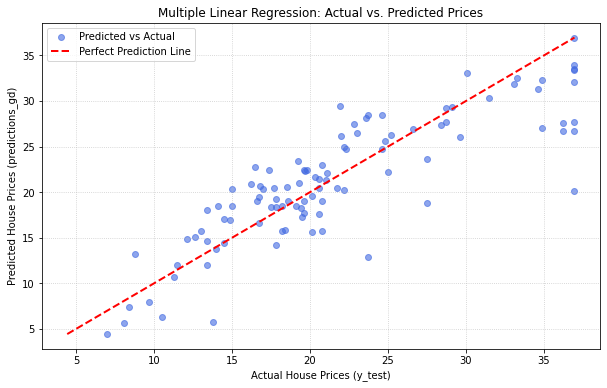

In [17]:
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(10, 6))

# Scatter plot of Actual vs. Predicted values
plt.scatter(y_test, predictions_gd, alpha=0.6, color='royalblue', label='Predicted vs Actual')

# Calculate the limits for the perfect fit line
max_val = max(np.max(y_test), np.max(predictions_gd))
min_val = min(np.min(y_test), np.min(predictions_gd))

# Plot the perfect fit line (y = x)
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Perfect Prediction Line')

# Add labels and title
plt.title('Multiple Linear Regression: Actual vs. Predicted Prices')
plt.xlabel('Actual House Prices (y_test)')
plt.ylabel('Predicted House Prices (predictions_gd)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)

# Show the plot
plt.show()